## Filtro Colaborativo

# ¿Cómo funciona?

Este modelo recomienda canciones a partir del comportamiento histórico de los usuarios, no del audio ni de la letra de las canciones.

## Idea general

1. Convertimos cada interacción en un valor numérico:
   - `like` = 3
   - `play` = 2
   - `skip` = 1

2. Construimos una matriz de usuarios vs. canciones.
   - Filas = usuarios
   - Columnas = canciones
   - Cada celda contiene el rating observado

3. Centramos los ratings por usuario.
   - Así reducimos el sesgo de usuarios que puntúan muy alto o muy bajo.

4. Aplicamos SVD truncado.
   - La descomposición encuentra factores latentes que resumen gustos similares.
   - Esos factores capturan patrones ocultos entre usuarios y canciones.

5. Generamos predicciones.
   - Para cada usuario, estimamos qué tan probable es que le guste cada canción.
   - Después descartamos las canciones que ya escuchó o calificó.

## En pocas palabras

"Usuarios con gustos parecidos tienden a disfrutar canciones parecidas."

Por eso, si el modelo detecta que tu patrón se parece al de otros usuarios, puede sugerir canciones que ellos valoraron bien y que tú todavía no has visto.

## Qué hace este notebook

- Carga y prepara los datos.
- Construye la matriz dispersa de interacciones.
- Aplica SVD para obtener factores latentes.
- Evalúa el modelo con RMSE y MAE.
- Genera recomendaciones para usuarios reales.


# Importaciones

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

sns.set_theme(style='whitegrid')
np.random.seed(42)

ITEMS_PATH = Path('/data/processed/items.csv')
if not ITEMS_PATH.exists():
	ITEMS_PATH = Path('../../data/processed/items.csv')
 
INTERACTIONS_PATH = Path('/data/processed/interactions.csv')
if not INTERACTIONS_PATH.exists():
	INTERACTIONS_PATH = Path('../../data/processed/interactions.csv')

# Mapeo de tipo de interacción a rating numérico
# La SVD necesita valores numéricos para aprender
RATING_MAP = {
    'like': 3.0,
    'play': 2.0,
    'skip': 1.0
}
RATING_SCALE = (1.0, 3.0)
K = 50


# Carga y Preparación de Datos

In [79]:
items        = pd.read_csv(ITEMS_PATH)
interactions = pd.read_csv(INTERACTIONS_PATH)

print(f'Canciones:     {len(items):,}')
print(f'Interacciones: {len(interactions):,}')

# Convertir EVENT_TYPE a rating numérico
interactions['rating'] = interactions['EVENT_TYPE'].map(RATING_MAP)

# Si un usuario interactuó varias veces con la misma canción → rating más alto
ratings = (
    interactions
    .groupby(['USER_ID', 'ITEM_ID'])['rating']
    .max()
    .reset_index()
)

print(f'\nPares únicos usuario-canción: {len(ratings):,}')
print(f'\nDistribución de ratings:')
print(ratings['rating'].value_counts().sort_index(ascending=False))

Canciones:     114,000
Interacciones: 750,050

Pares únicos usuario-canción: 750,050

Distribución de ratings:
rating
3.0    336727
2.0    273703
1.0    139620
Name: count, dtype: int64


# Matriz de Usuarios y Canciones

In [80]:
# Índices numéricos para usuarios y canciones
usuarios  = sorted(ratings['USER_ID'].unique())
canciones = sorted(ratings['ITEM_ID'].unique())

user_to_idx = {u: i for i, u in enumerate(usuarios)}
item_to_idx = {s: i for i, s in enumerate(canciones)}
idx_to_item = {i: s for s, i in item_to_idx.items()}

n_users = len(usuarios)
n_items = len(canciones)

# Construir la matriz como sparse para evitar usar gigabytes de RAM
row_idx = ratings['USER_ID'].map(user_to_idx).to_numpy()
col_idx = ratings['ITEM_ID'].map(item_to_idx).to_numpy()
values = ratings['rating'].to_numpy(dtype=float)

R = coo_matrix((values, (row_idx, col_idx)), shape=(n_users, n_items)).tocsr()

densidad = R.nnz / (R.shape[0] * R.shape[1]) * 100
print(f'Matriz: {R.shape}  ({n_users} usuarios × {n_items} canciones)')
print(f'Densidad: {densidad:.4f}%')
print(f'El SVD predecirá el {100 - densidad:.2f}% restante')


Matriz: (15001, 89639)  (15001 usuarios × 89639 canciones)
Densidad: 0.0558%
El SVD predecirá el 99.94% restante


# SVD

In [81]:
# --- Train/Test split por usuario y SVD sobre train (validación por usuario) ---
# Holdout por usuario: dejamos 1 interacción por usuario en test cuando sea posible

def train_test_per_user(ratings_df, n_test_per_user=1, min_interactions=1, seed=42):
    np.random.seed(seed)
    train_parts = []
    test_parts = []

    for uid, group in ratings_df.groupby('USER_ID'):
        if len(group) <= min_interactions:
            train_parts.append(group)
            continue
        n_test = min(n_test_per_user, len(group))
        test_idx = np.random.choice(group.index, size=n_test, replace=False)
        test_parts.append(group.loc[test_idx])
        train_parts.append(group.drop(test_idx))

    train = pd.concat(train_parts).reset_index(drop=True)
    test  = pd.concat(test_parts).reset_index(drop=True) if len(test_parts) > 0 else pd.DataFrame(columns=ratings_df.columns)
    return train, test

train_ratings, test_ratings = train_test_per_user(ratings, n_test_per_user=1, min_interactions=1)
print(f'Train pares: {len(train_ratings):,} | Test pares: {len(test_ratings):,}')

# Construir matriz sparse de train
row_idx_train = train_ratings['USER_ID'].map(user_to_idx).to_numpy()
col_idx_train = train_ratings['ITEM_ID'].map(item_to_idx).to_numpy()
values_train  = train_ratings['rating'].to_numpy(dtype=float)

R_train = coo_matrix((values_train, (row_idx_train, col_idx_train)), shape=(n_users, n_items)).tocsr()
print(f'R_train shape: {R_train.shape} | nnz: {R_train.nnz}')

# Medias por usuario (solo train)
conteo_u_train = np.asarray(R_train.getnnz(axis=1)).ravel()
suma_u_train = np.asarray(R_train.sum(axis=1)).ravel()
media_u_train = np.divide(
    suma_u_train,
    conteo_u_train,
    out=np.zeros_like(suma_u_train, dtype=float),
    where=conteo_u_train > 0
)

# Centrar sin densificar
R_train_center = R_train.tocoo(copy=True).astype(float)
R_train_center.data = R_train_center.data - media_u_train[R_train_center.row]
R_train_center = R_train_center.tocsr()

# SVD truncado sobre train
k_train = min(K, min(R_train_center.shape) - 1)
if k_train < 1:
    raise ValueError('No hay suficientes usuarios o items para SVD en train')

print(f'Aplicando SVD sobre train con K={k_train}...')
U_train, S_train, Vt_train = svds(R_train_center, k=k_train)
factores_usuario_train = U_train * S_train
print('SVD (train) completado')
print(f'U_train: {U_train.shape} | S_train: {S_train.shape} | Vt_train: {Vt_train.shape}')

# Predecir solo para el conjunto test en lotes
if len(test_ratings) > 0:
    test_u = test_ratings['USER_ID'].map(user_to_idx).to_numpy()
    test_i = test_ratings['ITEM_ID'].map(item_to_idx).to_numpy()
    reals = test_ratings['rating'].to_numpy(dtype=float)

    preds = np.empty(len(test_ratings), dtype=float)
    chunk = 100_000
    for start in range(0, len(test_ratings), chunk):
        end = min(len(test_ratings), start + chunk)
        f = test_u[start:end]
        c = test_i[start:end]
        preds[start:end] = np.einsum('ij,ij->i', factores_usuario_train[f], Vt_train.T[c]) + media_u_train[f]

    preds = np.clip(preds, RATING_SCALE[0], RATING_SCALE[1])

    rmse_test = np.sqrt(mean_squared_error(reals, preds))
    mae_test  = mean_absolute_error(reals, preds)
    print(f'Test RMSE: {rmse_test:.4f} | Test MAE: {mae_test:.4f}')
else:
    print('No hay pares en test para evaluar')

# Guardar objetos de validación para uso posterior
R_train_vars = dict(
    R_train=R_train,
    U_train=U_train, S_train=S_train, Vt_train=Vt_train,
    factores_usuario_train=factores_usuario_train, media_u_train=media_u_train,
    train_ratings=train_ratings, test_ratings=test_ratings
)


Train pares: 735,049 | Test pares: 15,001
R_train shape: (15001, 89639) | nnz: 735049
Aplicando SVD sobre train con K=50...
SVD (train) completado
U_train: (15001, 50) | S_train: (50,) | Vt_train: (50, 89639)
Test RMSE: 0.7624 | Test MAE: 0.6655


# Evaluación de Modelo

In [82]:
# Evaluar solo en celdas que SÍ tenían rating real
filas, columnas = R.nonzero()
reales = R[filas, columnas].A1

# Calcular predicciones en lotes para no crear matrices intermedias gigantes
predichos = np.empty_like(reales, dtype=float)
chunk_size = 100_000
for inicio in range(0, len(filas), chunk_size):
    fin = inicio + chunk_size
    f = filas[inicio:fin]
    c = columnas[inicio:fin]
    predichos[inicio:fin] = np.einsum('ij,ij->i', factores_usuario[f], Vt.T[c]) + media_usuarios[f]

# Mantener las predicciones dentro de la escala original
predichos = np.clip(predichos, 1.0, 3.0)

rmse = np.sqrt(mean_squared_error(reales, predichos))
mae  = mean_absolute_error(reales, predichos)

print(f'RMSE:{rmse:.4f}  (error en escala 1-3)')
print(f'MAE:{mae:.4f}')
print(f'\n -> En promedio el modelo se equivoca {mae:.2f} puntos en la escala 1-3')

RMSE:0.7391  (error en escala 1-3)
MAE:0.6440

 -> En promedio el modelo se equivoca 0.64 puntos en la escala 1-3


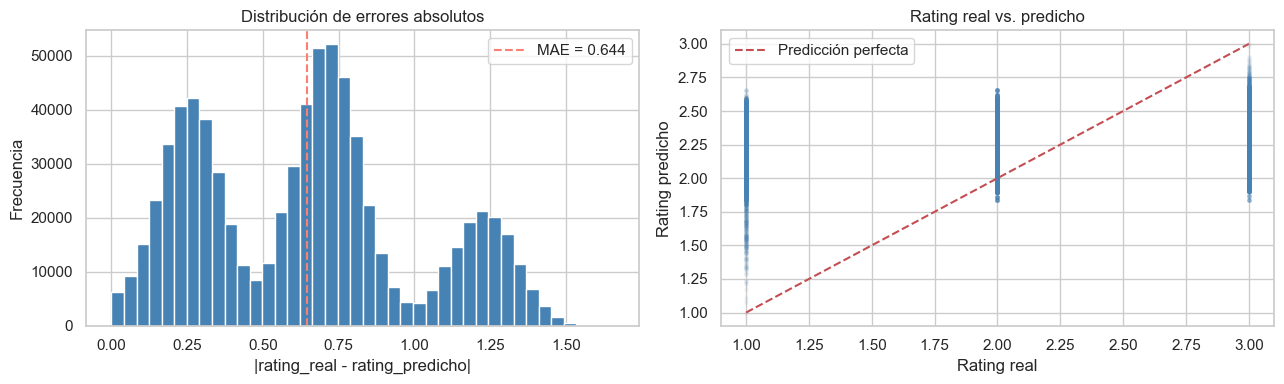

In [83]:
errores = np.abs(reales - predichos)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(errores, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(mae, color='salmon', linestyle='--', label=f'MAE = {mae:.3f}')
axes[0].set_title('Distribución de errores absolutos')
axes[0].set_xlabel('|rating_real - rating_predicho|')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].scatter(reales, predichos, alpha=0.05, s=6, color='steelblue')
axes[1].plot([1, 3], [1, 3], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].set_title('Rating real vs. predicho')
axes[1].set_xlabel('Rating real')
axes[1].set_ylabel('Rating predicho')
axes[1].legend()

plt.tight_layout()
plt.show()

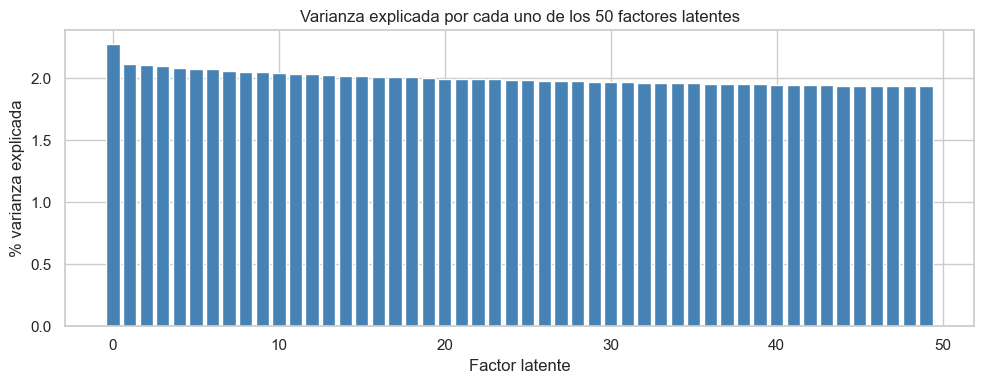

Los primeros 10 factores explican el 21.0% de la varianza total


In [84]:
# Varianza explicada por cada factor latente
varianza = (S ** 2) / (S ** 2).sum() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(S)), sorted(varianza, reverse=True), color='steelblue', edgecolor='white')
ax.set_title(f'Varianza explicada por cada uno de los {K} factores latentes')
ax.set_xlabel('Factor latente')
ax.set_ylabel('% varianza explicada')
plt.tight_layout()
plt.show()

top10 = sum(sorted(varianza, reverse=True)[:10])
print(f'Los primeros 10 factores explican el {top10:.1f}% de la varianza total')

# Función de Recomendación

In [85]:
items_indexed = items.drop_duplicates('ITEM_ID').set_index('ITEM_ID')


def recomendar_collaborative(user_id: str, n: int = 10) -> pd.DataFrame:
    """
    Recomienda las N canciones con mayor score colaborativo para el usuario.
    """
    if user_id not in user_to_idx:
        print(f'Usuario {user_id} no encontrado en el modelo.')
        return pd.DataFrame()

    u_idx = user_to_idx[user_id]

    # Puntajes para todas las canciones a partir de los factores latentes
    scores_usuario = (factores_usuario[u_idx] @ Vt) + media_usuarios[u_idx]
    scores_usuario = np.asarray(scores_usuario).ravel().copy()

    # No recomendar canciones ya vistas
    ya_vistas = interactions.loc[interactions['USER_ID'] == user_id, 'ITEM_ID'].tolist()
    for item_id in ya_vistas:
        if item_id in item_to_idx:
            scores_usuario[item_to_idx[item_id]] = -np.inf

    # Top N
    top_indices = np.argsort(scores_usuario)[::-1][:n]
    top_items = [idx_to_item[i] for i in top_indices]
    top_scores = scores_usuario[top_indices]

    resultado = items_indexed.loc[top_items, ['titulo', 'artista', 'genero', 'popularidad']].copy()
    resultado['score_colaborativo'] = top_scores

    return resultado.reset_index()


print('Función recomendar_collaborative() definida')

Función recomendar_collaborative() definida


# Prueba con Usuarios Reales

In [86]:
usuario_prueba = interactions[
    interactions['EVENT_TYPE'] == 'like'
]['USER_ID'].value_counts().index[0]

likes = interactions[
    (interactions['USER_ID'] == usuario_prueba) &
    (interactions['EVENT_TYPE'] == 'like')
]['ITEM_ID'].tolist()

print(f'Usuario de prueba: {usuario_prueba} ({len(likes)} likes)')
print('\nSus likes:')
items_indexed.loc[
    [i for i in likes[:5] if i in items_indexed.index],
    ['titulo', 'artista', 'genero']
]

Usuario de prueba: user_4558 (36 likes)

Sus likes:


,titulo,artista,genero
ITEM_ID,,,
3jwcudvYIksoAjU0x6gagd,Valerie,Steve Winwood,country
7tCL3GNUc04W2S7Cx1MzId,Serene Rain,Deep Sleep Rain Sounds,sleep
1wrSlSMgdb4STao5UKN5ML,Rough Day,Rain Sounds,sleep
76CSHuHKMJxmjmdrNBX2Z3,Victoria’s Secret,Jax,singer-songwriter
1kJvdhrr9MHOZ1e1PhTXTG,Drown,Prateek Kuhad,folk


In [87]:
recomendaciones_cf = recomendar_collaborative(usuario_prueba, n=10)
print(f'Top 10 recomendaciones (Collaborative) para {usuario_prueba}:')
recomendaciones_cf

Top 10 recomendaciones (Collaborative) para user_4558:


,ITEM_ID,titulo,artista,genero,popularidad,score_colaborativo
0,0T7DQlfcadEUEjxoHeQQaL,Labios Rotos - En Vivo,Zoé,alt-rock,0,2.605157
1,6q7bXTv3yBedHblKRoC5uu,Kadam,Prateek Kuhad,folk,51,2.597786
2,5U0t4SMp344ER0F4jYb6xI,The Boys Of Summer,Don Henley,country,0,2.596802
3,7eTy1IzCaICfm6JYy1BV4u,with you/for you,Prateek Kuhad,folk,46,2.596531
4,5RhWszHMSKzb7KiXk4Ae0M,One Last Kiss,Hikaru Utada,anime,65,2.594338
5,73fRMyckZKtemX14eku8uu,Dandini Dandini Dastana,Sertab Erener,j-pop,48,2.593433
6,6lVtX3nLHyWZP7aqU9HuVW,Heads Will Roll,Yeah Yeah Yeahs,alt-rock,0,2.593187
7,6CqIPNIgAYmbOyPgVKv0u3,Christmas Time's A-Coming,Emmylou Harris,country,0,2.591086
8,1ml3WGeluftee3DiSfyIGx,Right Down the Line,Gerry Rafferty,country,0,2.588724
9,4aqS25F3ywJ9TGnNkOqilC,Abracadabra - Remastered 2017,Steve Miller Band,blues,2,2.588195


In [88]:
# Prueba con cualquier usuario
USER_ID_PRUEBA = 'user_5001'
resultado = recomendar_collaborative(USER_ID_PRUEBA, n=10)
print(f'Recomendaciones para {USER_ID_PRUEBA}:')
resultado

Recomendaciones para user_5001:


,ITEM_ID,titulo,artista,genero,popularidad,score_colaborativo
0,2Ey6v4Sekh3Z0RUSISRosD,Layla,Derek & The Dominos,blues,0,2.440381
1,5h1L6nOR9QYXeeNW14aeus,Pause,Prateek Kuhad,folk,51,2.430877
2,5TuTzdZVv2k4Gtl7Rn6pow,Lamento Boliviano,Los Enanitos Verdes,alt-rock,0,2.428376
3,7y5uK11sbFNiNEafUvntSL,Dragula,Rob Zombie,alt-rock,0,2.425168
4,54zCdkbIALAnv8Ihi3XWlD,Stay Alive,José González,folk,0,2.424499
5,2aibwv5hGXSgw7Yru8IYTO,Snow (Hey Oh),Red Hot Chili Peppers,alt-rock,80,2.422353
6,05fL1P3yj5DLIE9mF7pf1z,What a Fool Believes,The Doobie Brothers,blues,0,2.418688
7,2QLFTiSNgt6cT3aQdeGFhd,Don't Shoot Me Santa,The Killers;Ryan Pardey,alt-rock,0,2.416855
8,4ymzjLJIaRsXoTvO8sfDpZ,The Werewolf,Paul Simon,folk,0,2.416699
9,2Zlqc4m6Gv0tSsgDS87LJQ,Ley Seca,Jhayco;Anuel AA,latin,0,2.416533


# Se guarda el Modelo

In [89]:
import pickle, os

MODEL_PATH = '../../data/processed/modelo_svd.pkl'
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

modelo = {
    'user_to_idx' : user_to_idx,
    'item_to_idx' : item_to_idx,
    'idx_to_item' : idx_to_item,
    'U': U, 'S': S, 'Vt': Vt,
    'media_usuarios': media_usuarios,
    'factores_usuario': factores_usuario
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(modelo, f)

print(f'Modelo guardado en: {MODEL_PATH}')
print('Será cargado por 03_hybrid.ipynb')

Modelo guardado en: ../../data/processed/modelo_svd.pkl
Será cargado por 03_hybrid.ipynb
